In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from imblearn.over_sampling import SMOTE

np.random.seed(42)

In [ ]:
with open('all_results.json', 'r') as f:
    raw = json.load(f)

ALL_CKV = ['CKV_AWS_300','CKV2_AWS_62','CKV2_AWS_64','CKV2_AWS_65',
           'CKV_AWS_145','CKV_AWS_21','CKV_AWS_144','CKV_AWS_18',
           'CKV2_AWS_6','CKV2_AWS_61','CKV_AWS_7']

ALL_AVD = ['AVD-AWS-0057','AVD-AWS-0065','AVD-AWS-0086','AVD-AWS-0087',
           'AVD-AWS-0088','AVD-AWS-0089','AVD-AWS-0090','AVD-AWS-0091',
           'AVD-AWS-0093','AVD-AWS-0094','AVD-AWS-0132']

# ── Feature extraction
rows = []
for key, entry in raw.items():
    ck = entry['checkov']
    tf = entry['tfsec']
    fail_rate = ck['failed'] / ck['total'] if ck['total'] > 0 else 0
    high_plus = tf['severity']['CRITICAL'] + tf['severity']['HIGH']
    failed_ids = set(ck['failure_names'])
    finding_ids = set(tf['findings'])
    row = {
        'key': key,
        'model': entry['model'],
        'prompt': entry['prompt'],
        'checkov_passed': ck['passed'],
        'checkov_failed': ck['failed'],
        'checkov_total': ck['total'],
        'checkov_fail_rate': fail_rate,
        'tfsec_total': tf['total'],
        'tfsec_high_plus': high_plus,
        'tfsec_medium': tf['severity']['MEDIUM'],
        'tfsec_low': tf['severity']['LOW'],
        'total_violations': ck['failed'] + tf['total'],
    }
    for ckv in ALL_CKV:
        row[ckv] = 1 if ckv in failed_ids else 0
    for avd in ALL_AVD:
        row[avd] = 1 if avd in finding_ids else 0
    rows.append(row)

df = pd.DataFrame(rows)
median_viol = df['total_violations'].median()
df['label'] = (df['total_violations'] <= median_viol).astype(int)

print(f'Dataset shape: {df.shape}')
print(f'Label threshold: total_violations <= {median_viol}')
print(f"Label distribution: {df['label'].value_counts().to_dict()}  (0=Insecure, 1=Secure)")
df[['model','prompt','checkov_failed','tfsec_high_plus','total_violations','label']]

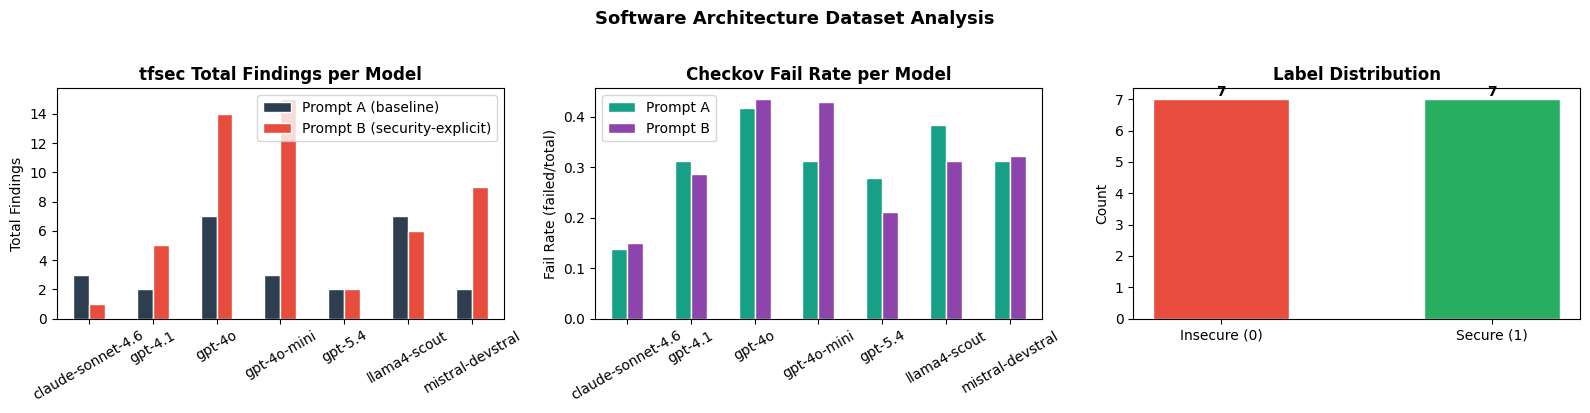

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
pivot = df.pivot(index='model', columns='prompt', values='tfsec_total')
pivot.plot(kind='bar', ax=ax, color=['#2c3e50','#e74c3c'], edgecolor='white')
ax.set_title('tfsec Total Findings per Model', fontweight='bold')
ax.set_ylabel('Total Findings')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Prompt A (baseline)','Prompt B (security-explicit)'])

ax = axes[1]
pivot2 = df.pivot(index='model', columns='prompt', values='checkov_fail_rate')
pivot2.plot(kind='bar', ax=ax, color=['#16a085','#8e44ad'], edgecolor='white')
ax.set_title('Checkov Fail Rate per Model', fontweight='bold')
ax.set_ylabel('Fail Rate (failed/total)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Prompt A','Prompt B'])

ax = axes[2]
counts = df['label'].value_counts()
ax.bar(['Insecure (0)','Secure (1)'], [counts.get(0,0), counts.get(1,0)],
       color=['#e74c3c','#27ae60'], edgecolor='white', width=0.5)
ax.set_title('Label Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    ax.text(i, v+0.1, str(v), ha='center', fontweight='bold')

plt.suptitle('Software Architecture Dataset Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig0_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
FEATURE_COLS = [
    'checkov_passed','checkov_failed','checkov_fail_rate',
    'tfsec_total','tfsec_high_plus','tfsec_medium','tfsec_low','total_violations',
] + ALL_CKV + ALL_AVD

X_base = df[FEATURE_COLS].values.astype(float)
y_base = df['label'].values

# Augment with Gaussian noise
FACTOR = 20
X_list, y_list = [X_base], [y_base]
for _ in range(FACTOR - 1):
    noise = np.random.normal(0, 0.3, X_base.shape)
    X_noisy = np.clip(X_base + noise, 0, None)
    # Clip binary features
    for i, col in enumerate(FEATURE_COLS):
        if col.startswith('CKV') or col.startswith('AVD'):
            X_noisy[:, i] = np.clip(np.round(X_noisy[:, i]), 0, 1)
    X_list.append(X_noisy)
    y_list.append(y_base)

X_aug = np.vstack(X_list)
y_aug = np.concatenate(y_list)
groups = np.tile(np.arange(len(X_base)), FACTOR)

print(f'Augmented: {X_aug.shape[0]} samples | Groups: {len(np.unique(groups))}')
print(f'Class balance: {dict(zip(*np.unique(y_aug, return_counts=True)))}')

Augmented: 280 samples | Groups: 14
Class balance (pre-SMOTE): {np.int64(0): np.int64(140), np.int64(1): np.int64(140)}


In [ ]:
MODELS = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))
    ]),
    'MLP Neural Net': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                               solver='adam', alpha=0.001, max_iter=500, random_state=42))
    ]),
}

In [ ]:
cv = GroupKFold(n_splits=5)
results = {}

for name, pipeline in MODELS.items():
    print(f'{name} ...', end='  ')
    y_preds = np.full(len(y_aug), -1)
    y_probs = np.zeros(len(y_aug))

    for train_idx, test_idx in cv.split(X_aug, y_aug, groups):
        X_tr, y_tr = X_aug[train_idx], y_aug[train_idx]
        X_te = X_aug[test_idx]

        if len(np.unique(y_tr)) > 1:
            k = min(4, min(np.bincount(y_tr.astype(int))) - 1)
            X_tr, y_tr = SMOTE(random_state=42, k_neighbors=max(1, k)).fit_resample(X_tr, y_tr)

        model = clone(pipeline)
        model.fit(X_tr, y_tr)
        y_preds[test_idx] = model.predict(X_te)
        y_probs[test_idx] = model.predict_proba(X_te)[:, 1]

    fpr, tpr, _ = roc_curve(y_aug, y_probs)
    results[name] = {
        'accuracy' : accuracy_score(y_aug, y_preds),
        'precision': precision_score(y_aug, y_preds, zero_division=0),
        'recall'   : recall_score(y_aug, y_preds, zero_division=0),
        'f1'       : f1_score(y_aug, y_preds, zero_division=0),
        'cm'       : confusion_matrix(y_aug, y_preds),
        'fpr'      : fpr,
        'tpr'      : tpr,
        'auc'      : auc(fpr, tpr),
    }
    r = results[name]
    print(f"Acc={r['accuracy']:.3f} | Prec={r['precision']:.3f} | Rec={r['recall']:.3f} | F1={r['f1']:.3f} | AUC={r['auc']:.3f}")

Logistic Regression ...  Acc=0.811 | Prec=0.792 | Rec=0.843 | F1=0.817 | AUC=0.831
Random Forest ...  Acc=0.857 | Prec=0.931 | Rec=0.771 | F1=0.844 | AUC=0.942
Gradient Boosting ...  Acc=0.857 | Prec=0.990 | Rec=0.721 | F1=0.835 | AUC=0.957
SVM (RBF) ...  Acc=0.786 | Prec=0.799 | Rec=0.764 | F1=0.781 | AUC=0.871
MLP Neural Net ...  Acc=0.818 | Prec=0.803 | Rec=0.843 | F1=0.822 | AUC=0.829


In [ ]:
looo_results = {name: {'y_true': [], 'y_pred': [], 'y_prob': []} for name in MODELS}

for i in range(len(X_base)):
    X_train_raw = np.delete(X_base, i, axis=0)
    y_train_raw = np.delete(y_base, i, axis=0)
    X_test_raw = X_base[i:i+1]
    y_test_raw = y_base[i:i+1]

    X_tr_list, y_tr_list = [X_train_raw], [y_train_raw]
    for _ in range(FACTOR - 1):
        noise = np.random.normal(0, 0.3, X_train_raw.shape)
        X_noisy = np.clip(X_train_raw + noise, 0, None)
        for j, col in enumerate(FEATURE_COLS):
            if col.startswith('CKV') or col.startswith('AVD'):
                X_noisy[:, j] = np.clip(np.round(X_noisy[:, j]), 0, 1)
        X_tr_list.append(X_noisy)
        y_tr_list.append(y_train_raw)

    X_tr_aug = np.vstack(X_tr_list)
    y_tr_aug = np.concatenate(y_tr_list)

    if len(np.unique(y_tr_aug)) > 1:
        k = min(4, int(np.sum(y_tr_aug == 1)) - 1)
        X_tr_final, y_tr_final = SMOTE(random_state=42, k_neighbors=max(1, k)).fit_resample(X_tr_aug, y_tr_aug)
    else:
        X_tr_final, y_tr_final = X_tr_aug, y_tr_aug

    for name, pipeline in MODELS.items():
        model = clone(pipeline)
        model.fit(X_tr_final, y_tr_final)
        looo_results[name]['y_true'].append(y_test_raw[0])
        looo_results[name]['y_pred'].append(model.predict(X_test_raw)[0])
        looo_results[name]['y_prob'].append(model.predict_proba(X_test_raw)[0, 1])

looo_comparison = pd.DataFrame({
    'Model': list(MODELS.keys()),
    'Augmented CV Acc': [results[n]['accuracy'] for n in MODELS],
    'LOOO Acc': [accuracy_score(np.array(looo_results[n]['y_true']), np.array(looo_results[n]['y_pred'])) for n in MODELS],
}).set_index('Model')
looo_comparison['Gap'] = looo_comparison['Augmented CV Acc'] - looo_comparison['LOOO Acc']
looo_comparison.style.background_gradient(cmap='RdYlGn_r', subset=['Gap']).format('{:.4f}')

,Augmented CV Acc,LOOO Acc,Gap
Model,,,
Logistic Regression,0.8107,0.8571,-0.0464
Random Forest,0.8571,0.9286,-0.0714
Gradient Boosting,0.8571,1.0000,-0.1429
SVM (RBF),0.7857,0.8571,-0.0714
MLP Neural Net,0.8179,0.8571,-0.0393


**RESULTS SECTION**

In [ ]:
summary = pd.DataFrame([
    {'Model': name, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
     'Recall': r['recall'], 'F1-Score': r['f1'], 'ROC-AUC': r['auc']}
    for name, r in results.items()
]).set_index('Model').round(4)

summary.style.background_gradient(cmap='Greens').format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8107,0.7919,0.8429,0.8166,0.8309
Random Forest,0.8571,0.9310,0.7714,0.8438,0.9416
Gradient Boosting,0.8571,0.9902,0.7214,0.8347,0.9566
SVM (RBF),0.7857,0.7985,0.7643,0.7810,0.8710
MLP Neural Net,0.8179,0.8027,0.8429,0.8223,0.8291


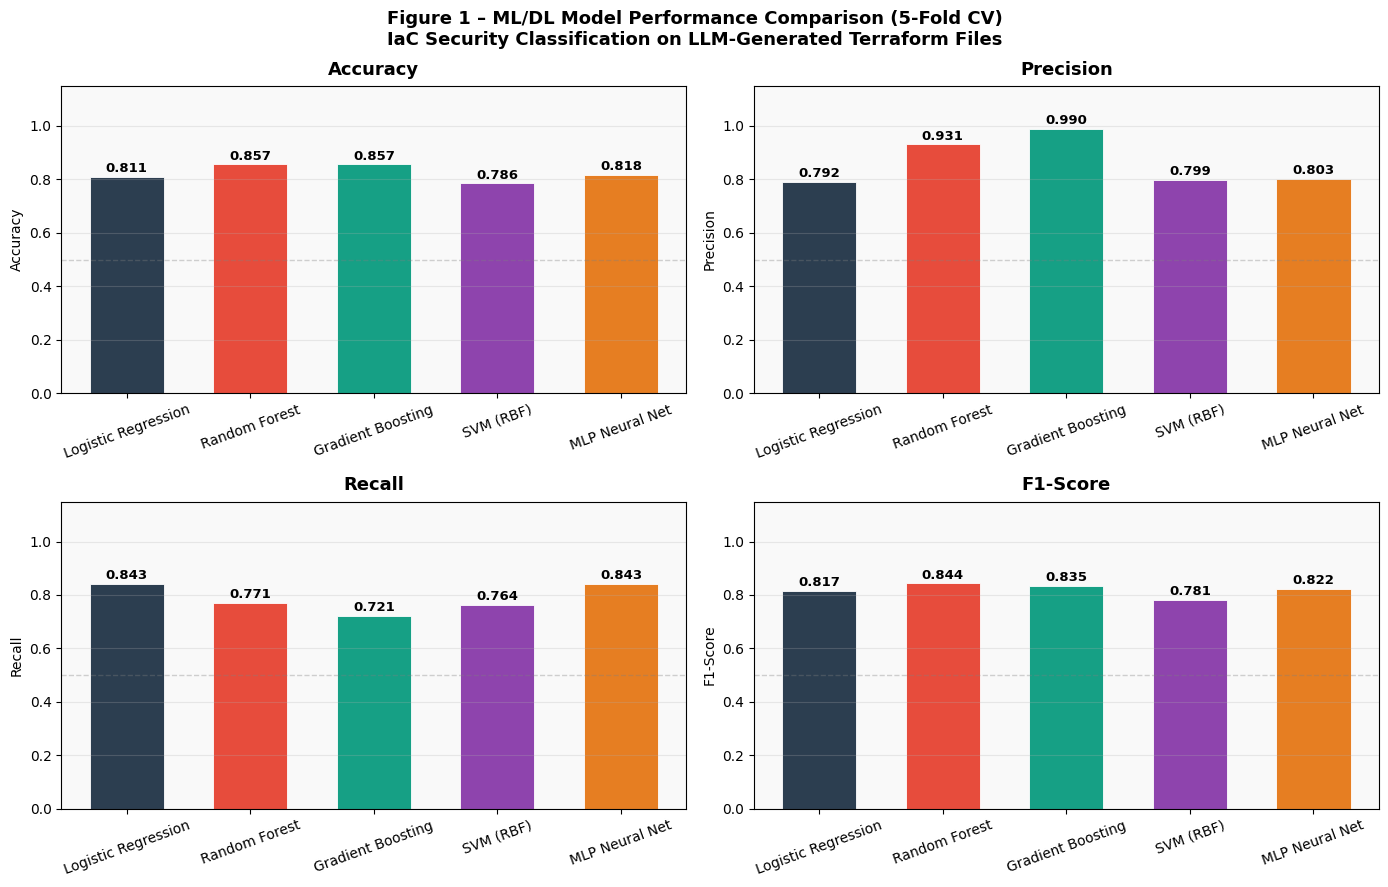

In [ ]:
COLORS = ['#2c3e50','#e74c3c','#16a085','#8e44ad','#e67e22']
metrics   = ['accuracy','precision','recall','f1']
m_labels  = ['Accuracy','Precision','Recall','F1-Score']
names     = list(results.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, (metric, label) in enumerate(zip(metrics, m_labels)):
    ax = axes[idx]
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=COLORS, edgecolor='white', linewidth=0.6, width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel(label)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.35, linewidth=1)
    ax.set_facecolor('#f9f9f9')
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Figure 1 – ML/DL Model Performance Comparison (5-Fold CV)\nIaC Security Classification on LLM-Generated Terraform Files',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

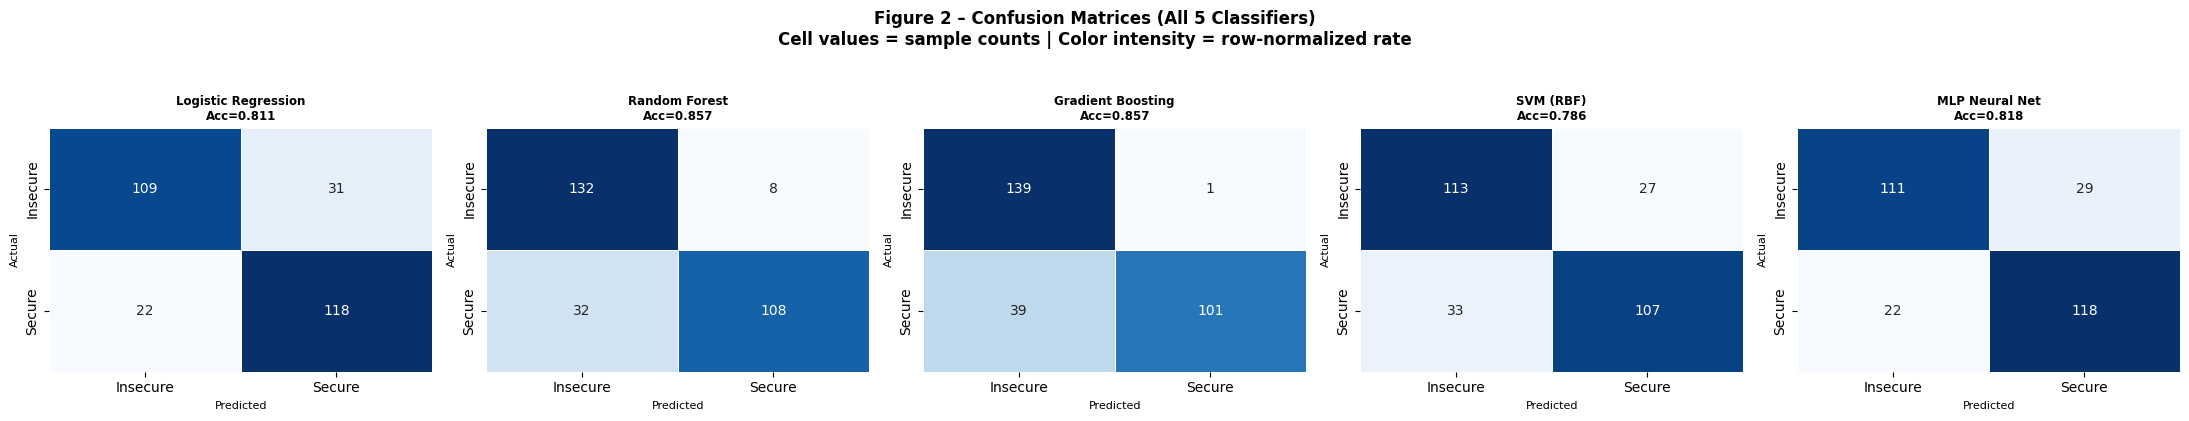

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm_norm = r['cm'].astype('float') / r['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=r['cm'], fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Insecure','Secure'], yticklabels=['Insecure','Secure'],
                cbar=False, linewidths=0.5, linecolor='white')
    ax.set_title(f"{name}\nAcc={r['accuracy']:.3f}", fontsize=8.5, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.suptitle('Figure 2 – Confusion Matrices (All 5 Classifiers)\nCell values = sample counts | Color intensity = row-normalized rate',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('fig2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

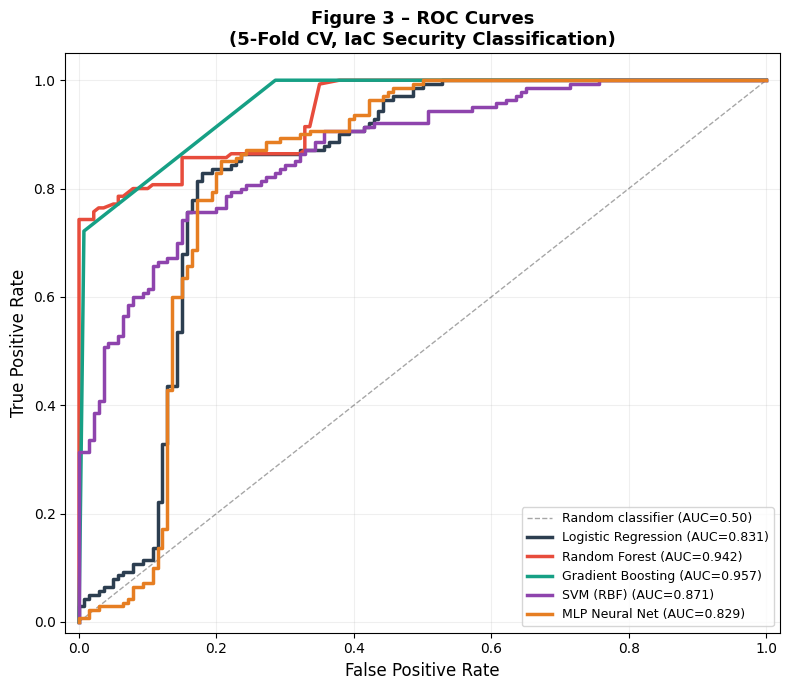

In [ ]:
ROC_COLORS = ['#2c3e50','#e74c3c','#16a085','#8e44ad','#e67e22']

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0,1],[0,1],'k--', alpha=0.35, linewidth=1, label='Random classifier (AUC=0.50)')

for (name, r), color in zip(results.items(), ROC_COLORS):
    ax.plot(r['fpr'], r['tpr'], color=color, linewidth=2.5,
            label=f"{name} (AUC={r['auc']:.3f})")

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 3 – ROC Curves\n(5-Fold CV, IaC Security Classification)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('fig3_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

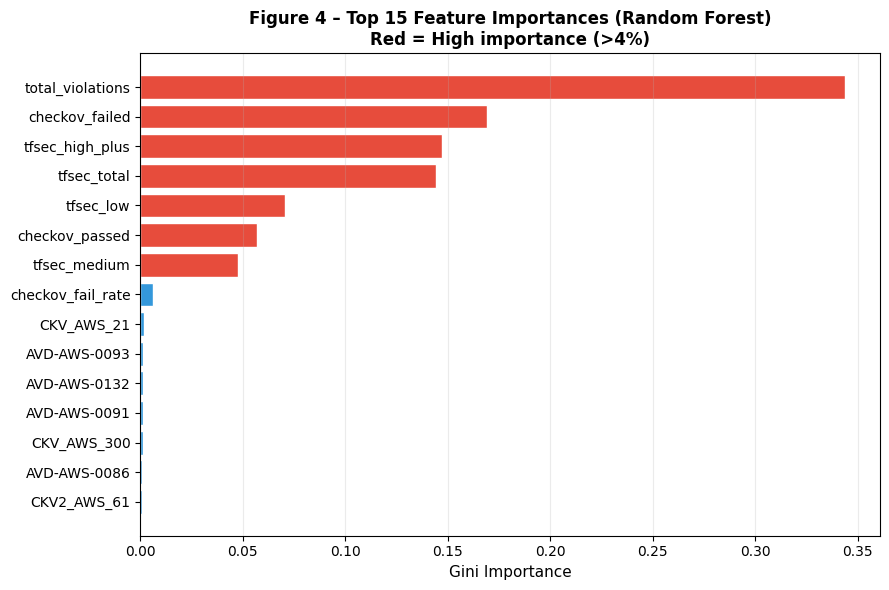

In [ ]:
rf_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))
])
rf_full.fit(X_aug, y_aug)

importances = rf_full.named_steps['clf'].feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})\
            .sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=['#e74c3c' if v > 0.04 else '#3498db' for v in feat_df['Importance']],
        edgecolor='white')
ax.set_xlabel('Gini Importance', fontsize=11)
ax.set_title('Figure 4 – Top 15 Feature Importances (Random Forest)\nRed = High importance (>4%)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

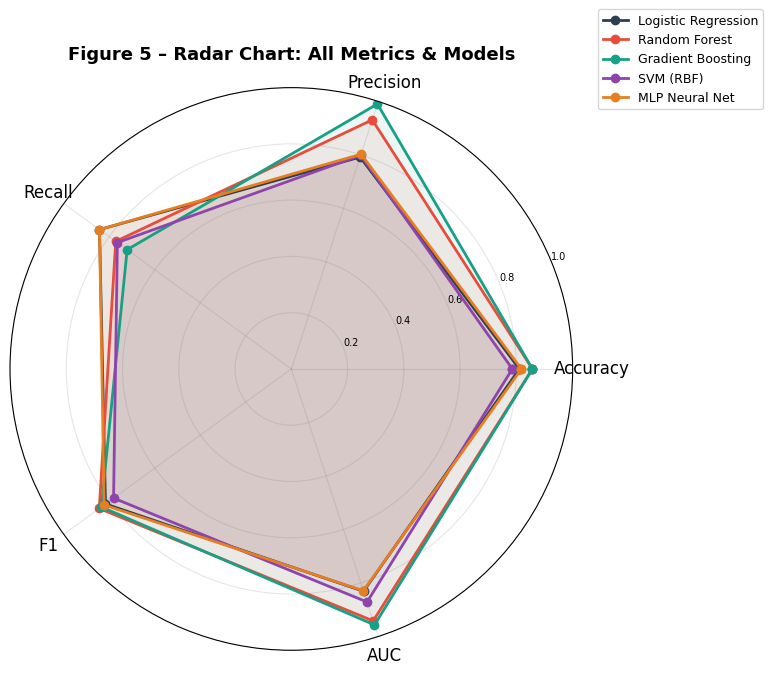

In [ ]:
metrics_r  = ['accuracy','precision','recall','f1','auc']
m_labels_r = ['Accuracy','Precision','Recall','F1','AUC']
N = len(metrics_r)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (name, r), color in zip(results.items(), ROC_COLORS):
    vals = [r[m] for m in metrics_r]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(m_labels_r, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax.grid(color='gray', alpha=0.2)
ax.set_title('Figure 5 – Radar Chart: All Metrics & Models', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('fig5_radar.png', dpi=150, bbox_inches='tight')
plt.show()